In [ ]:

import pandas as pd


df_train = pd.read_csv('processed_train_data.csv')
df_test = pd.read_csv('processed_test_data.csv')

# X ve y olarak ayır
X_train_final = df_train.drop('RainTomorrow', axis=1)
y_train = df_train['RainTomorrow']

X_test_final = df_test.drop('RainTomorrow', axis=1)
y_test = df_test['RainTomorrow']

print(" Veriler yüklendi")

 Veriler yüklendi


In [ ]:

try:
    
    from imblearn.over_sampling import SMOTE
except ImportError:
    pass

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,  
                               ExtraTreesClassifier 
                              )
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score

#  SMOTE  VERİ DENGELEME
print(" [FİNAL] SMOTE Uygulanıyor...")
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print(f" SMOTE verisi hazır: {X_train_smote.shape}")

 [FİNAL] SMOTE Uygulanıyor...
 SMOTE verisi hazır: (176504, 60)


In [ ]:
#  ADABOOST & STACKING  ---
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt

# 1. AdaBoost Tuning
print("  AdaBoost Optimize Ediliyor...")
param_dist_ada = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 1.0)
}
ada_search = RandomizedSearchCV(AdaBoostClassifier(random_state=42), param_dist_ada, 
                                n_iter=10, cv=3, scoring='f1', n_jobs=-1, random_state=42)
ada_search.fit(X_train_smote, y_train_smote)
best_ada = ada_search.best_estimator_
print(f" AdaBoost En İyi: {ada_search.best_params_}")


print(" Stacking Modeli Kuruluyor...")
estimators = [
    ('rf', RandomForestClassifier(n_estimators=174, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=199, eval_metric='logloss', random_state=42, n_jobs=-1))
]
stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=3, n_jobs=-1)
stack_model.fit(X_train_smote, y_train_smote)
print(" Stacking Eğitildi.")



  AdaBoost Optimize Ediliyor...
 AdaBoost En İyi: {'learning_rate': np.float64(0.6111150117432088), 'n_estimators': 180}
 Stacking Modeli Kuruluyor...
 Stacking Eğitildi.


 Ensemble Modelleri (AdaBoost & Stacking) Eğitiliyor...
  AdaBoost eğitiliyor...
  Stacking Classifier eğitiliyor...


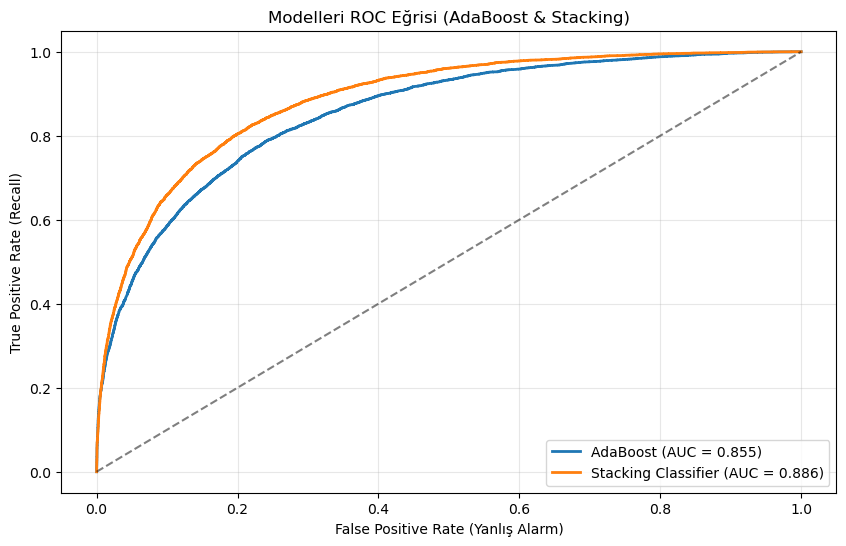


 DETAYLI PERFORMANS TABLOSU
------------------------------------------------------------


,Balanced Accuracy,Accuracy,Precision (Class 1),Recall (Class 1),F1 Score (Class 1),AUC Score
Model,,,,,,
AdaBoost,0.7666,0.7959,0.5335,0.7134,0.6105,0.8553
Stacking Classifier,0.7831,0.8428,0.6421,0.6748,0.6580,0.8857


In [ ]:
# =============================================================================
#  ENSEMBLE MODELLERİ 
# =============================================================================
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, recall_score, 
                             precision_score, balanced_accuracy_score, roc_curve)
import pandas as pd
import matplotlib.pyplot as plt



stack_estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=174,        
        max_features='log2',     
        min_samples_split=4,     
        random_state=42, n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=199,        
        learning_rate=0.0216,    
        max_depth=7,             
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
]

# 2. Modelleri Tanımla
member_4_models = [
    ("AdaBoost", AdaBoostClassifier(
        n_estimators=180,          
        learning_rate=0.6111,      
        random_state=42
    )),
    ("Stacking Classifier", StackingClassifier(
        estimators=stack_estimators, 
        final_estimator=LogisticRegression(), 
        cv=3, 
        n_jobs=-1
    ))
]

results = []
plt.figure(figsize=(10, 6))
print(" Ensemble Modelleri (AdaBoost & Stacking) Eğitiliyor...")

for name, model in member_4_models:
    print(f"  {name} eğitiliyor...")
    
    #  Eğitim 
    model.fit(X_train_smote, y_train_smote)
    
    #  Tahmin (Test Verisi İle)
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1] # ROC için olasılık
    
    # Metriklerin Hesaplanması
    metrics = {
        "Model": name,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Class 1)": precision_score(y_test, y_pred),
        "Recall (Class 1)": recall_score(y_test, y_pred),
        "F1 Score (Class 1)": f1_score(y_test, y_pred),
        "AUC Score": roc_auc_score(y_test, y_prob)
    }
    results.append(metrics)
    
    # D) ROC Eğrisi Çizimi
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["AUC Score"]:.3f})', linewidth=2)

# Grafik Ayarları
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Modelleri ROC Eğrisi (AdaBoost & Stacking)')
plt.xlabel('False Positive Rate (Yanlış Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Tabloyu Göster
df_res = pd.DataFrame(results).set_index("Model")
print("\n DETAYLI PERFORMANS TABLOSU")
print("-" * 60)

try:
    display(df_res.style.format("{:.4f}"))
except:
    print(df_res)

In [ ]:
#PyTorch Derin Ogrenme

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Çalışma Ortamı: {device}")


X_train_pt = torch.tensor(X_train_smote.values, dtype=torch.float32).to(device)
y_train_pt = torch.tensor(y_train_smote.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_pt = torch.tensor(X_test_final.values, dtype=torch.float32).to(device)
y_test_pt = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)


train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
input_dim = X_train_pt.shape[1]

# 4. EĞİTİM FONKSİYONU 
def train_and_evaluate(model, model_name, epochs=15):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print(f"  {model_name} eğitiliyor...")
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        y_pred_prob = model(X_test_pt).cpu().numpy()
        y_pred_class = (y_pred_prob > 0.5).astype(float)
        
    y_test_np = y_test_pt.cpu().numpy()
    
    # Metrikler
    metrics = {
        "Model": f"[DL-PyTorch] {model_name}",
        "Accuracy": accuracy_score(y_test_np, y_pred_class),
        "F1 Score (Weighted)": f1_score(y_test_np, y_pred_class, average='weighted'),
        "Recall (Weighted)": recall_score(y_test_np, y_pred_class, average='weighted'),
        "AUC Score": roc_auc_score(y_test_np, y_pred_prob)
    }
    
    # Sınıf Bazlı
    report = classification_report(y_test_np, y_pred_class, output_dict=True)
    class_metrics = [
        {"Model": f"[DL-PyTorch] {model_name}", "Class": "1 (Rain)", 
         "Precision": report['1.0']['precision'], "Recall": report['1.0']['recall'], "F1-Score": report['1.0']['f1-score']}
    ]
    return metrics, class_metrics

print("Tamamlandı")

Çalışma Ortamı: cpu
Tamamlandı


In [17]:
# =============================================================================
# RESNET (SKIP CONNECTION) & TANH ACTIVATION
# =============================================================================
class somer_ResNetANN(nn.Module):
    def __init__(self, input_dim):
        super(somer_ResNetANN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.shortcut = nn.Linear(input_dim, 64) 
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.layer1(x))
        out = self.relu(self.layer2(out) + identity)
        return self.sigmoid(self.out(out))

class somer_TanhANN(nn.Module):
    def __init__(self, input_dim):
        super(somer_TanhANN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 25)
        self.out = nn.Linear(25, 1)
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.tanh(self.layer1(x))
        x = self.tanh(self.layer2(x))
        return self.sigmoid(self.out(x))


models = [(somer_ResNetANN(input_dim), "somer_ResNet"), (somer_TanhANN(input_dim), "somer_TanhANN")]
genel, sinif = [], []

for m, n in models:
    g, s = train_and_evaluate(m, n)
    genel.append(g); sinif.extend(s)

pd.DataFrame(genel).to_csv('somer_DL_genel1.csv', index=False)
pd.DataFrame(sinif).to_csv('somer_DL_sinif1.csv', index=False)
print(" Hazır")

  somer_ResNet eğitiliyor...
  somer_TanhANN eğitiliyor...
 Hazır
